In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

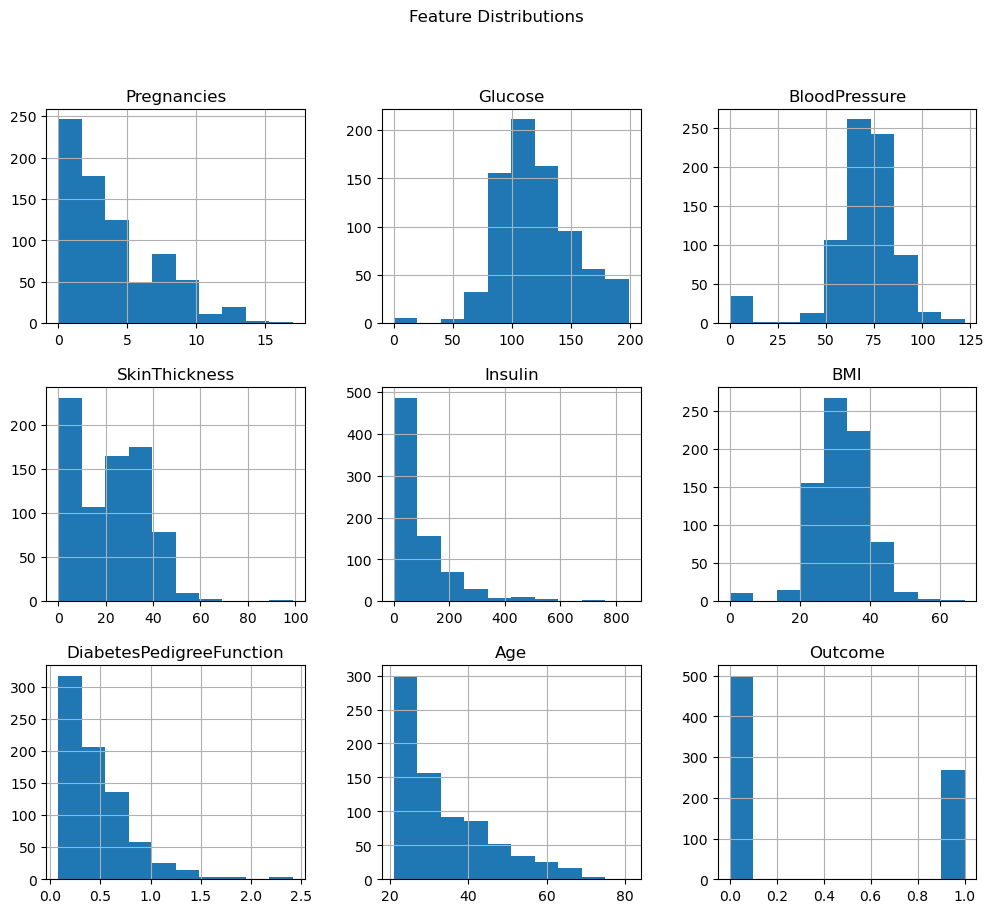

In [9]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

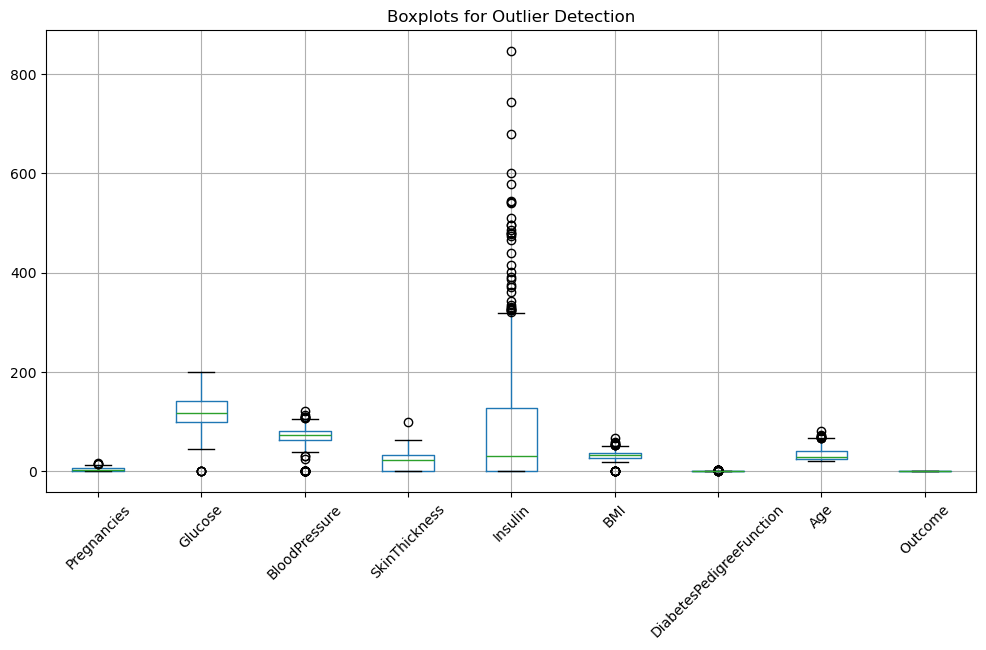

In [10]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots for Outlier Detection")
plt.show()

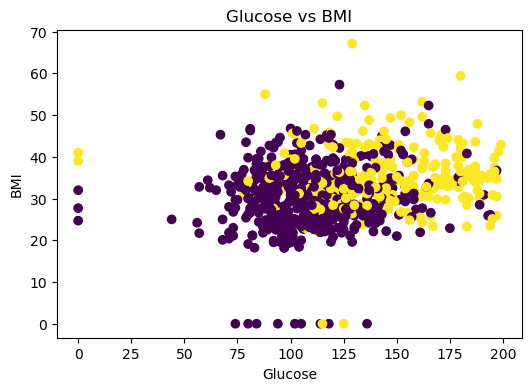

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df['Glucose'], df['BMI'], c=df['Outcome'])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

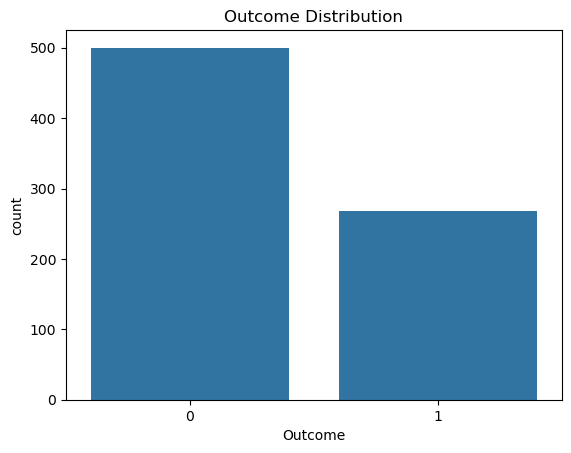

In [12]:
import seaborn as sns

sns.countplot(x='Outcome', data=df)
plt.title("Outcome Distribution")
plt.show()

In [13]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [14]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.7 MB/s  0:00:00


In [18]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [19]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
prec_lgbm = precision_score(y_test, y_pred_lgbm)
rec_lgbm = recall_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

In [22]:
from sklearn.model_selection import cross_val_score

cv_lgbm = cross_val_score(
    lgbm,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

cv_xgb = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("LGBM CV Accuracy:", cv_lgbm.mean())
print("XGB CV Accuracy:", cv_xgb.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000177 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 667
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_lgbm.fit(X_train, y_train)

print(grid_lgbm.best_params_)
print(grid_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 143, number of negative: 266
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 512
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349633 -> initscore=-0.620652
[LightGBM] [Info] Start training from score -0.620652
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [24]:
grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)


{'max_depth': 3, 'n_estimators': 100}
0.7410728519049896


In [25]:
comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1 Score"],
    "LightGBM":[acc_lgbm, prec_lgbm, rec_lgbm, f1_lgbm],
    "XGBoost":[acc_xgb, prec_xgb, rec_xgb, f1_xgb]
})

print(comparison)

      Metric  LightGBM   XGBoost
0   Accuracy  0.766234  0.759740
1  Precision  0.680000  0.673469
2     Recall  0.629630  0.611111
3   F1 Score  0.653846  0.640777


In [29]:
from sklearn.metrics import classification_report

print("LightGBM Report")
print(classification_report(y_test, y_pred_lgbm))

print("\nXGBoost Report")
print(classification_report(y_test, y_pred_xgb))

LightGBM Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154


XGBoost Report
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



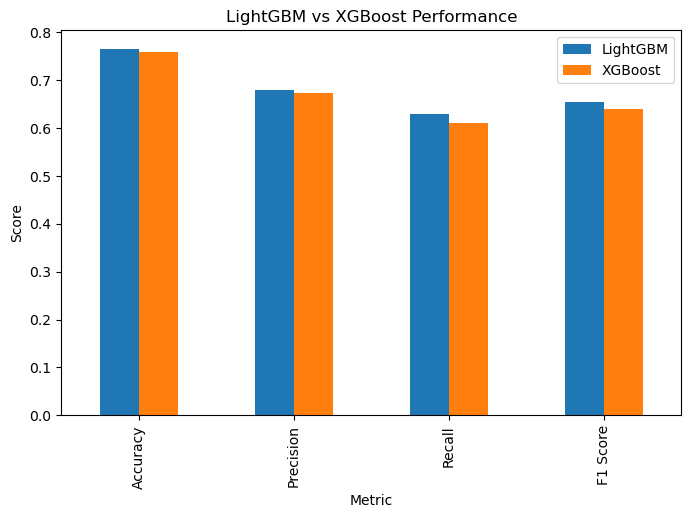

In [28]:
comparison.set_index("Metric").plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("LightGBM vs XGBoost Performance")
plt.ylabel("Score")
plt.show()

In [31]:
best_lgbm = grid_lgbm.best_estimator_
print(best_lgbm)
best_xgb = grid_xgb.best_estimator_
print(best_xgb)

LGBMClassifier(max_depth=5, n_estimators=50, random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)


In [27]:
print("""
Conclusion:
1. LightGBM and XGBoost were trained on the Diabetes dataset.
2. Missing values were handled using median imputation.
3. Both models achieved strong classification performance.
4. Cross-validation and hyperparameter tuning improved model reliability.
5. XGBoost generally provides higher predictive power but may require more training time.
6. LightGBM is faster and more memory efficient on larger datasets.
7. The better model is selected based on Accuracy, Precision, Recall and F1-Score results.
""")


Conclusion:
1. LightGBM and XGBoost were trained on the Diabetes dataset.
2. Missing values were handled using median imputation.
3. Both models achieved strong classification performance.
4. Cross-validation and hyperparameter tuning improved model reliability.
5. XGBoost generally provides higher predictive power but may require more training time.
6. LightGBM is faster and more memory efficient on larger datasets.
7. The better model is selected based on Accuracy, Precision, Recall and F1-Score results.

